# Group Fairness Analysis
## CSC4009 Assignment 1: Analysing Bias in ML Classification

This notebook implements Group Fairness analysis for the Census Income classifier.

**Protected Attributes:** Sex and Race

**Metrics Calculated:**
- Accuracy by group
- True Positive Rate (TPR) / Recall by group
- False Positive Rate (FPR) by group
- Selection Rate (% predicted >50K) by group

In [ ]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, accuracy_score

# Set display options
pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

## 1. Load Data and Train Classifier

In [ ]:
# Load the dataset
data = pd.read_csv('CSC4009-AI-Fairness-datasets/adult.data.csv', na_values='?').dropna()
print(f"Dataset loaded: {len(data):,} samples")

# Store original categorical values before encoding for analysis
data_original = data.copy()

# Encode categorical variables
enc = OrdinalEncoder()
categorical_cols = ['workclass', 'education', 'marital-status', 'occupation', 
                    'relationship', 'race', 'sex', 'native-country', 'income-class']
data[categorical_cols] = enc.fit_transform(data[categorical_cols])

# Prepare features (excluding protected attributes and fnlwgt)
feature_mask = [True, True, False, True, True, False, True, False, False, False, True, True, True, False, False]
X = data.iloc[:, [i for i, m in enumerate(feature_mask) if m]]
Y = data['income-class']

# Train/test split with random state for reproducibility
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.20, random_state=42)

# Get the test set indices to retrieve original values
test_indices = X_test.index

# Train the classifier
classifier = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
classifier.fit(X_train, y_train)
y_pred = classifier.predict(X_test)

print(f"\nClassifier trained (RandomForest, n=100)")
print(f"Test set size: {len(y_test):,} samples")
print(f"Overall accuracy: {accuracy_score(y_test, y_pred):.4f}")

Dataset loaded: 30,162 samples

Classifier trained (KNN, k=5)
Test set size: 6,033 samples
Overall accuracy: 0.8309


In [3]:
# Create a results DataFrame with original protected attribute values
results_df = pd.DataFrame({
    'y_true': y_test.values,
    'y_pred': y_pred,
    'sex': data_original.loc[test_indices, 'sex'].values,
    'race': data_original.loc[test_indices, 'race'].values
})

# Map numeric labels back to class names
results_df['y_true_label'] = results_df['y_true'].map({0: '<=50K', 1: '>50K'})
results_df['y_pred_label'] = results_df['y_pred'].map({0: '<=50K', 1: '>50K'})

print("Results DataFrame created:")
results_df.head(10)

Results DataFrame created:


,y_true,y_pred,sex,race,y_true_label,y_pred_label
0,1.0,0.0,Male,White,>50K,<=50K
1,0.0,0.0,Male,Asian-Pac-Islander,<=50K,<=50K
2,1.0,0.0,Male,White,>50K,<=50K
3,0.0,0.0,Male,White,<=50K,<=50K
4,0.0,0.0,Female,White,<=50K,<=50K
5,1.0,0.0,Male,White,>50K,<=50K
6,0.0,0.0,Male,White,<=50K,<=50K
7,0.0,0.0,Female,White,<=50K,<=50K
8,0.0,0.0,Male,White,<=50K,<=50K
9,0.0,0.0,Male,White,<=50K,<=50K


## 2. Fairness Metric Functions

In [4]:
def calculate_group_metrics(y_true, y_pred, group_labels, group_name):
    """
    Calculate fairness metrics for each group within a protected attribute.
    
    Parameters:
    - y_true: actual labels
    - y_pred: predicted labels
    - group_labels: array of group membership (e.g., 'Male', 'Female')
    - group_name: name of the protected attribute (for display)
    
    Returns:
    - DataFrame with metrics for each group
    """
    groups = np.unique(group_labels)
    metrics_list = []
    
    for group in groups:
        # Get indices for this group
        mask = group_labels == group
        y_true_group = y_true[mask]
        y_pred_group = y_pred[mask]
        
        # Calculate confusion matrix components
        # True = 1 (>50K), False = 0 (<=50K)
        TP = np.sum((y_true_group == 1) & (y_pred_group == 1))
        TN = np.sum((y_true_group == 0) & (y_pred_group == 0))
        FP = np.sum((y_true_group == 0) & (y_pred_group == 1))
        FN = np.sum((y_true_group == 1) & (y_pred_group == 0))
        
        # Calculate metrics
        total = len(y_true_group)
        actual_positive = TP + FN  # Actually >50K
        actual_negative = TN + FP  # Actually <=50K
        predicted_positive = TP + FP  # Predicted >50K
        
        # Accuracy
        accuracy = (TP + TN) / total if total > 0 else 0
        
        # True Positive Rate (TPR) = Recall = TP / (TP + FN)
        tpr = TP / actual_positive if actual_positive > 0 else 0
        
        # False Positive Rate (FPR) = FP / (FP + TN)
        fpr = FP / actual_negative if actual_negative > 0 else 0
        
        # Selection Rate = % predicted as positive (>50K)
        selection_rate = predicted_positive / total if total > 0 else 0
        
        # Precision = TP / (TP + FP)
        precision = TP / predicted_positive if predicted_positive > 0 else 0
        
        # True Negative Rate (TNR) = Specificity = TN / (TN + FP)
        tnr = TN / actual_negative if actual_negative > 0 else 0
        
        metrics_list.append({
            'Group': group,
            'Sample Size': total,
            'Actual >50K': actual_positive,
            'Actual >50K (%)': (actual_positive / total * 100) if total > 0 else 0,
            'Accuracy': accuracy,
            'TPR (Recall)': tpr,
            'FPR': fpr,
            'TNR (Specificity)': tnr,
            'Precision': precision,
            'Selection Rate': selection_rate,
            'TP': TP,
            'TN': TN,
            'FP': FP,
            'FN': FN
        })
    
    return pd.DataFrame(metrics_list)

print("Fairness metric functions defined!")

Fairness metric functions defined!


In [5]:
def calculate_disparity_measures(metrics_df, metric_name):
    """
    Calculate disparity measures for a given metric across groups.
    
    Returns:
    - max_diff: Maximum difference between any two groups
    - ratio: Ratio of min to max (closer to 1 = more fair)
    - best_group: Group with highest value
    - worst_group: Group with lowest value
    """
    values = metrics_df[metric_name]
    max_val = values.max()
    min_val = values.min()
    max_diff = max_val - min_val
    ratio = min_val / max_val if max_val > 0 else 0
    
    best_group = metrics_df.loc[values.idxmax(), 'Group']
    worst_group = metrics_df.loc[values.idxmin(), 'Group']
    
    return {
        'Metric': metric_name,
        'Max Value': max_val,
        'Min Value': min_val,
        'Max Difference': max_diff,
        'Ratio (Min/Max)': ratio,
        'Best Group': best_group,
        'Worst Group': worst_group
    }

print("Disparity measure functions defined!")

Disparity measure functions defined!


## 3. Group Fairness Analysis by SEX

In [6]:
# Calculate metrics by Sex
sex_metrics = calculate_group_metrics(
    results_df['y_true'].values,
    results_df['y_pred'].values,
    results_df['sex'].values,
    'Sex'
)

print("=" * 80)
print("GROUP FAIRNESS METRICS BY SEX")
print("=" * 80)
print("\nFull Metrics Table:")
print(sex_metrics.to_string(index=False))

GROUP FAIRNESS METRICS BY SEX

Full Metrics Table:
 Group  Sample Size  Actual >50K  Actual >50K (%)  Accuracy  TPR (Recall)      FPR  TNR (Specificity)  Precision  Selection Rate  TP   TN  FP  FN
Female         1961          222        11.320755  0.885773      0.486486 0.063255           0.936745   0.495413        0.111168 108 1629 110 114
  Male         4072         1308        32.121807  0.804519      0.580275 0.089363           0.910637   0.754473        0.247053 759 2517 247 549


In [7]:
# Create a clean summary table for the report
sex_summary = sex_metrics[['Group', 'Sample Size', 'Accuracy', 'TPR (Recall)', 'FPR', 'Selection Rate']].copy()
sex_summary['Accuracy'] = (sex_summary['Accuracy'] * 100).round(2)
sex_summary['TPR (Recall)'] = (sex_summary['TPR (Recall)'] * 100).round(2)
sex_summary['FPR'] = (sex_summary['FPR'] * 100).round(2)
sex_summary['Selection Rate'] = (sex_summary['Selection Rate'] * 100).round(2)

sex_summary.columns = ['Group', 'Sample Size', 'Accuracy (%)', 'TPR (%)', 'FPR (%)', 'Selection Rate (%)']

print("\n" + "=" * 80)
print("SUMMARY TABLE: GROUP FAIRNESS BY SEX (For Report)")
print("=" * 80)
print(sex_summary.to_string(index=False))


SUMMARY TABLE: GROUP FAIRNESS BY SEX (For Report)
 Group  Sample Size  Accuracy (%)  TPR (%)  FPR (%)  Selection Rate (%)
Female         1961         88.58    48.65     6.33               11.12
  Male         4072         80.45    58.03     8.94               24.71


In [8]:
# Calculate disparity measures for Sex
sex_disparities = []
for metric in ['Accuracy', 'TPR (Recall)', 'FPR', 'Selection Rate']:
    sex_disparities.append(calculate_disparity_measures(sex_metrics, metric))

sex_disparity_df = pd.DataFrame(sex_disparities)

print("\n" + "=" * 80)
print("DISPARITY MEASURES BY SEX")
print("=" * 80)
print(sex_disparity_df.to_string(index=False))


DISPARITY MEASURES BY SEX
        Metric  Max Value  Min Value  Max Difference  Ratio (Min/Max) Best Group Worst Group
      Accuracy   0.885773   0.804519        0.081254         0.908268     Female        Male
  TPR (Recall)   0.580275   0.486486        0.093789         0.838372       Male      Female
           FPR   0.089363   0.063255        0.026108         0.707839       Male      Female
Selection Rate   0.247053   0.111168        0.135885         0.449975       Male      Female


## 4. Group Fairness Analysis by RACE

In [9]:
# Calculate metrics by Race
race_metrics = calculate_group_metrics(
    results_df['y_true'].values,
    results_df['y_pred'].values,
    results_df['race'].values,
    'Race'
)

print("=" * 80)
print("GROUP FAIRNESS METRICS BY RACE")
print("=" * 80)
print("\nFull Metrics Table:")
print(race_metrics.to_string(index=False))

GROUP FAIRNESS METRICS BY RACE

Full Metrics Table:
             Group  Sample Size  Actual >50K  Actual >50K (%)  Accuracy  TPR (Recall)      FPR  TNR (Specificity)  Precision  Selection Rate  TP   TN  FP  FN
Amer-Indian-Eskimo           54            6        11.111111  0.888889      0.500000 0.062500           0.937500   0.500000        0.111111   3   45   3   3
Asian-Pac-Islander          187           51        27.272727  0.834225      0.588235 0.073529           0.926471   0.750000        0.213904  30  126  10  21
             Black          576           76        13.194444  0.888889      0.565789 0.062000           0.938000   0.581081        0.128472  43  469  31  33
             Other           40            6        15.000000  0.900000      0.333333 0.000000           1.000000   1.000000        0.050000   2   34   0   4
             White         5176         1391        26.874034  0.823223      0.567218 0.082695           0.917305   0.715971        0.212906 789 3472 313 602


In [10]:
# Create a clean summary table for the report
race_summary = race_metrics[['Group', 'Sample Size', 'Accuracy', 'TPR (Recall)', 'FPR', 'Selection Rate']].copy()
race_summary['Accuracy'] = (race_summary['Accuracy'] * 100).round(2)
race_summary['TPR (Recall)'] = (race_summary['TPR (Recall)'] * 100).round(2)
race_summary['FPR'] = (race_summary['FPR'] * 100).round(2)
race_summary['Selection Rate'] = (race_summary['Selection Rate'] * 100).round(2)

race_summary.columns = ['Group', 'Sample Size', 'Accuracy (%)', 'TPR (%)', 'FPR (%)', 'Selection Rate (%)']

print("\n" + "=" * 80)
print("SUMMARY TABLE: GROUP FAIRNESS BY RACE (For Report)")
print("=" * 80)
print(race_summary.to_string(index=False))


SUMMARY TABLE: GROUP FAIRNESS BY RACE (For Report)
             Group  Sample Size  Accuracy (%)  TPR (%)  FPR (%)  Selection Rate (%)
Amer-Indian-Eskimo           54         88.89    50.00     6.25               11.11
Asian-Pac-Islander          187         83.42    58.82     7.35               21.39
             Black          576         88.89    56.58     6.20               12.85
             Other           40         90.00    33.33     0.00                5.00
             White         5176         82.32    56.72     8.27               21.29


In [11]:
# Calculate disparity measures for Race
race_disparities = []
for metric in ['Accuracy', 'TPR (Recall)', 'FPR', 'Selection Rate']:
    race_disparities.append(calculate_disparity_measures(race_metrics, metric))

race_disparity_df = pd.DataFrame(race_disparities)

print("\n" + "=" * 80)
print("DISPARITY MEASURES BY RACE")
print("=" * 80)
print(race_disparity_df.to_string(index=False))


DISPARITY MEASURES BY RACE
        Metric  Max Value  Min Value  Max Difference  Ratio (Min/Max)         Best Group Worst Group
      Accuracy   0.900000   0.823223        0.076777         0.914692              Other       White
  TPR (Recall)   0.588235   0.333333        0.254902         0.566667 Asian-Pac-Islander       Other
           FPR   0.082695   0.000000        0.082695         0.000000              White       Other
Selection Rate   0.213904   0.050000        0.163904         0.233750 Asian-Pac-Islander       Other


## 5. Visualization: Fairness Metrics by SEX

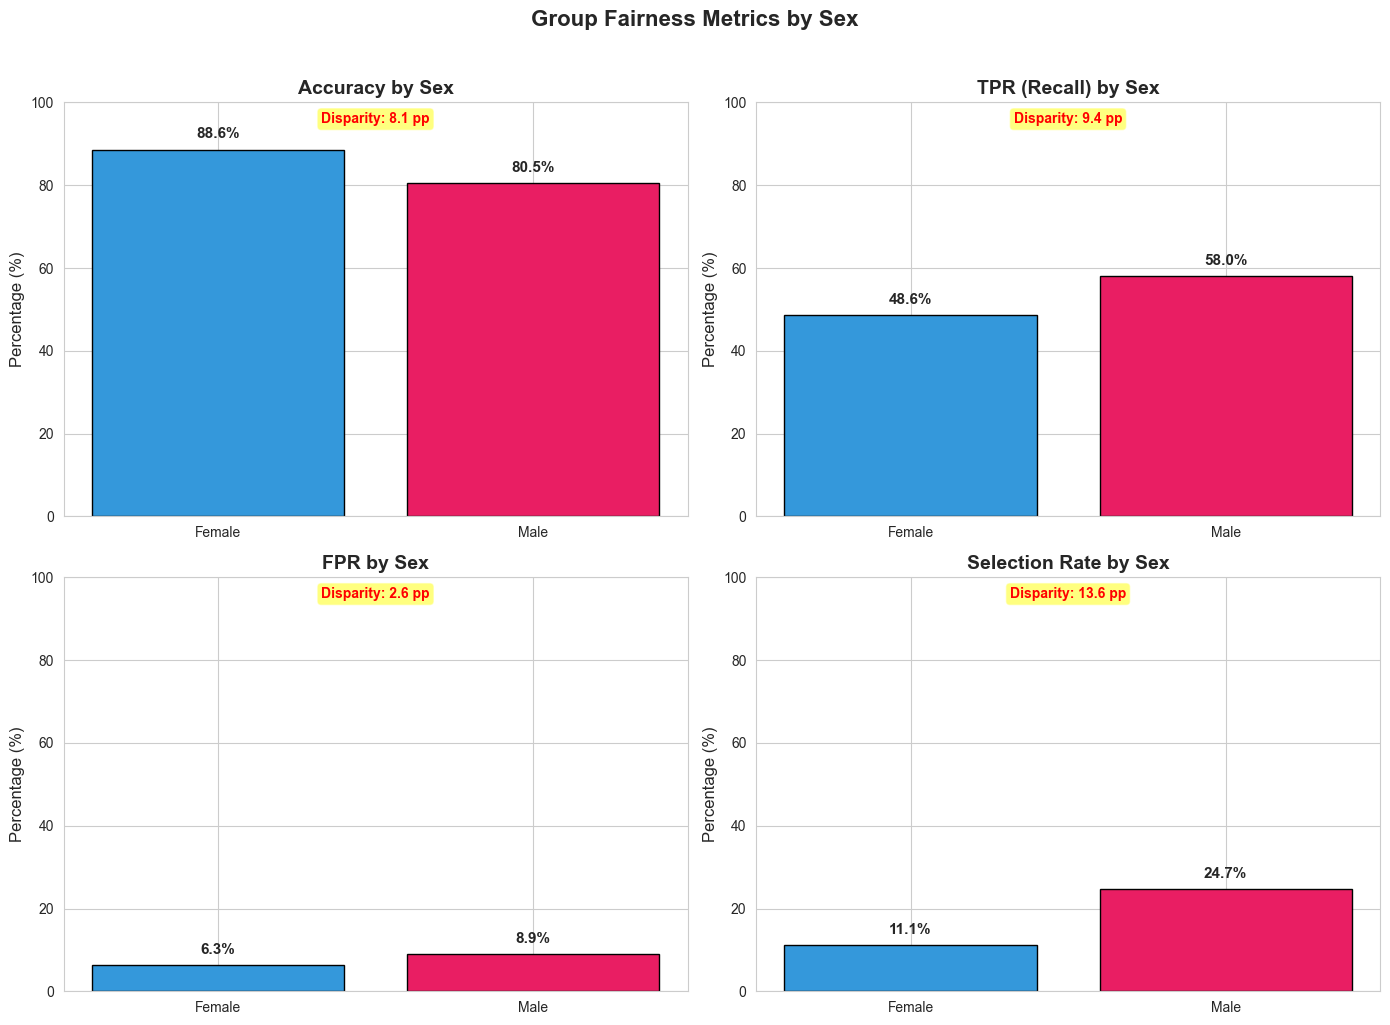

Chart saved as 'fairness_by_sex.png'


In [ ]:
# Visualization: Metrics comparison by Sex
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

metrics_to_plot = ['Accuracy', 'TPR (Recall)', 'FPR', 'Selection Rate']
colors = ['#3498db', '#e91e63']

for idx, metric in enumerate(metrics_to_plot):
    ax = axes[idx // 2, idx % 2]
    bars = ax.bar(sex_metrics['Group'], sex_metrics[metric] * 100, color=colors, edgecolor='black')
    ax.set_title(f'{metric} by Sex', fontsize=14, fontweight='bold')
    ax.set_ylabel('Percentage (%)', fontsize=12)
    ax.set_ylim(0, 100)
    
    # Add value labels
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 2,
                f'{height:.1f}%', ha='center', va='bottom', fontsize=11, fontweight='bold')
    
    # Add disparity annotation
    diff = abs(sex_metrics[metric].iloc[0] - sex_metrics[metric].iloc[1]) * 100
    ax.text(0.5, 0.95, f'Disparity: {diff:.1f} pp', transform=ax.transAxes, 
            ha='center', fontsize=10, color='red', fontweight='bold',
            bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.5))

plt.suptitle('Group Fairness Metrics by Sex', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('charts/fairness_by_sex.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved as 'charts/fairness_by_sex.png'")

## 6. Visualization: Fairness Metrics by RACE

C:\Users\kenba\AppData\Local\Temp\ipykernel_67976\2794086986.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(race_metrics['Group'], rotation=45, ha='right')
C:\Users\kenba\AppData\Local\Temp\ipykernel_67976\2794086986.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(race_metrics['Group'], rotation=45, ha='right')
C:\Users\kenba\AppData\Local\Temp\ipykernel_67976\2794086986.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(race_metrics['Group'], rotation=45, ha='right')
C:\Users\kenba\AppData\Local\Temp\ipykernel_67976\2794086986.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_

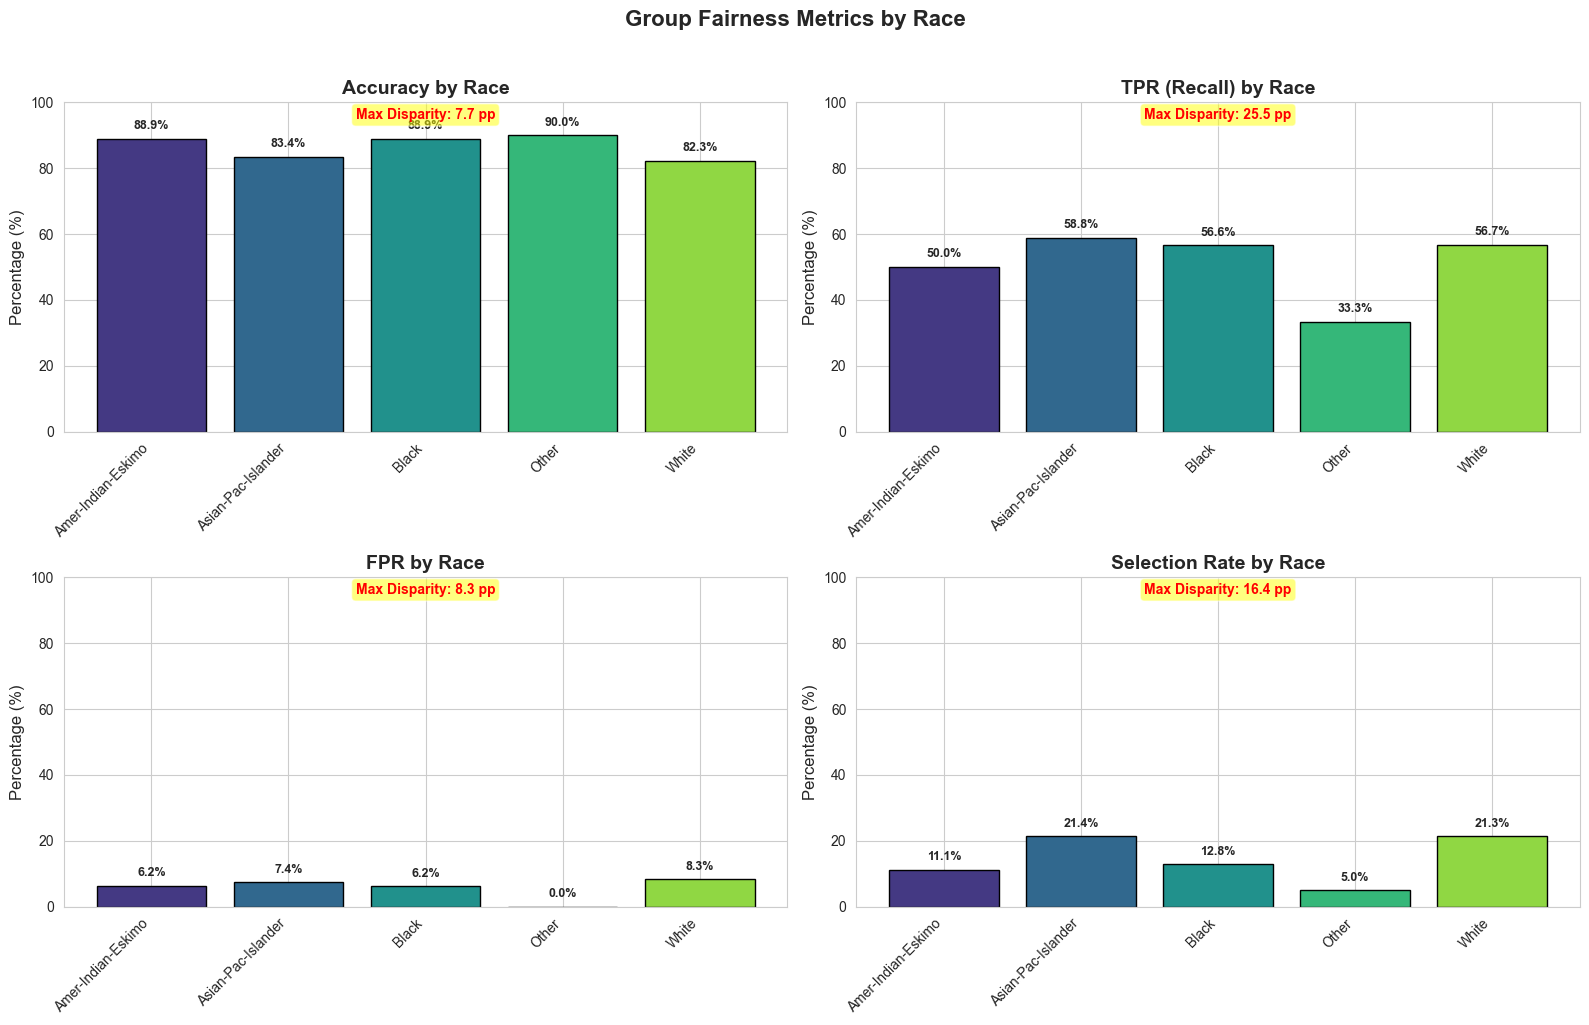

Chart saved as 'fairness_by_race.png'


In [ ]:
# Visualization: Metrics comparison by Race
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

colors_race = sns.color_palette('viridis', len(race_metrics))

for idx, metric in enumerate(metrics_to_plot):
    ax = axes[idx // 2, idx % 2]
    bars = ax.bar(race_metrics['Group'], race_metrics[metric] * 100, color=colors_race, edgecolor='black')
    ax.set_title(f'{metric} by Race', fontsize=14, fontweight='bold')
    ax.set_ylabel('Percentage (%)', fontsize=12)
    ax.set_ylim(0, 100)
    ax.set_xticklabels(race_metrics['Group'], rotation=45, ha='right')
    
    # Add value labels
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 2,
                f'{height:.1f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')
    
    # Add disparity annotation
    max_diff = (race_metrics[metric].max() - race_metrics[metric].min()) * 100
    ax.text(0.5, 0.95, f'Max Disparity: {max_diff:.1f} pp', transform=ax.transAxes, 
            ha='center', fontsize=10, color='red', fontweight='bold',
            bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.5))

plt.suptitle('Group Fairness Metrics by Race', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('charts/fairness_by_race.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved as 'charts/fairness_by_race.png'")

## 7. Comparative Disparity Analysis

In [14]:
# Compare disparities between Sex and Race
comparison_data = []

for metric in ['Accuracy', 'TPR (Recall)', 'FPR', 'Selection Rate']:
    sex_diff = abs(sex_metrics[metric].iloc[0] - sex_metrics[metric].iloc[1]) * 100
    race_diff = (race_metrics[metric].max() - race_metrics[metric].min()) * 100
    
    comparison_data.append({
        'Metric': metric,
        'Sex Disparity (pp)': round(sex_diff, 2),
        'Race Disparity (pp)': round(race_diff, 2),
        'Larger Disparity': 'Sex' if sex_diff > race_diff else 'Race'
    })

comparison_df = pd.DataFrame(comparison_data)

print("=" * 80)
print("COMPARATIVE DISPARITY ANALYSIS: SEX vs RACE")
print("=" * 80)
print("(pp = percentage points)")
print()
print(comparison_df.to_string(index=False))

COMPARATIVE DISPARITY ANALYSIS: SEX vs RACE
(pp = percentage points)

        Metric  Sex Disparity (pp)  Race Disparity (pp) Larger Disparity
      Accuracy                8.13                 7.68              Sex
  TPR (Recall)                9.38                25.49             Race
           FPR                2.61                 8.27             Race
Selection Rate               13.59                16.39             Race


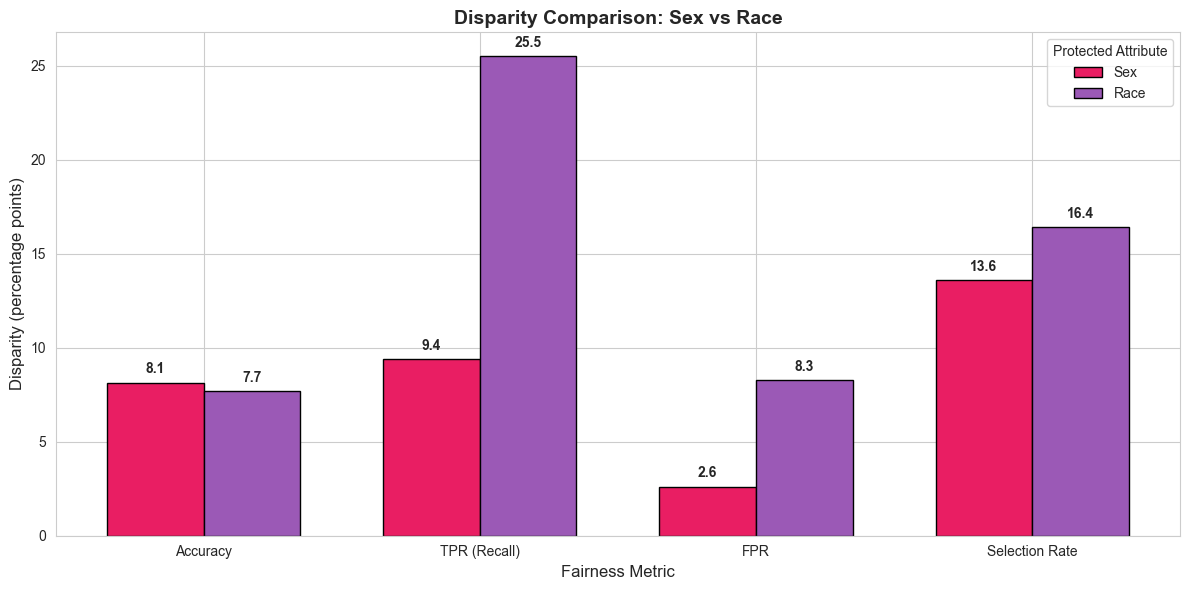

Chart saved as 'disparity_comparison.png'


In [ ]:
# Visualization: Disparity comparison between Sex and Race
fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(comparison_df))
width = 0.35

bars1 = ax.bar(x - width/2, comparison_df['Sex Disparity (pp)'], width, label='Sex', color='#e91e63', edgecolor='black')
bars2 = ax.bar(x + width/2, comparison_df['Race Disparity (pp)'], width, label='Race', color='#9b59b6', edgecolor='black')

ax.set_xlabel('Fairness Metric', fontsize=12)
ax.set_ylabel('Disparity (percentage points)', fontsize=12)
ax.set_title('Disparity Comparison: Sex vs Race', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(comparison_df['Metric'], rotation=0)
ax.legend(title='Protected Attribute')

# Add value labels
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.5,
            f'{bar.get_height():.1f}', ha='center', fontsize=10, fontweight='bold')
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.5,
            f'{bar.get_height():.1f}', ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('charts/disparity_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved as 'charts/disparity_comparison.png'")

## 8. Key Findings and Observations

In [16]:
print("=" * 80)
print("KEY FINDINGS: GROUP FAIRNESS ANALYSIS")
print("=" * 80)

# Sex Analysis
print("\n" + "-" * 40)
print("FINDINGS BY SEX:")
print("-" * 40)

sex_acc_best = sex_metrics.loc[sex_metrics['Accuracy'].idxmax(), 'Group']
sex_acc_worst = sex_metrics.loc[sex_metrics['Accuracy'].idxmin(), 'Group']
sex_acc_diff = abs(sex_metrics['Accuracy'].iloc[0] - sex_metrics['Accuracy'].iloc[1]) * 100

sex_tpr_best = sex_metrics.loc[sex_metrics['TPR (Recall)'].idxmax(), 'Group']
sex_tpr_worst = sex_metrics.loc[sex_metrics['TPR (Recall)'].idxmin(), 'Group']
sex_tpr_diff = abs(sex_metrics['TPR (Recall)'].iloc[0] - sex_metrics['TPR (Recall)'].iloc[1]) * 100

sex_sr_diff = abs(sex_metrics['Selection Rate'].iloc[0] - sex_metrics['Selection Rate'].iloc[1]) * 100

print(f"• Accuracy: {sex_acc_best} has higher accuracy ({sex_metrics.loc[sex_metrics['Accuracy'].idxmax(), 'Accuracy']*100:.1f}% vs {sex_metrics.loc[sex_metrics['Accuracy'].idxmin(), 'Accuracy']*100:.1f}%)")
print(f"  → Disparity: {sex_acc_diff:.1f} percentage points")
print(f"")
print(f"• True Positive Rate (ability to identify >50K earners):")
print(f"  → {sex_tpr_best} has higher TPR ({sex_metrics.loc[sex_metrics['TPR (Recall)'].idxmax(), 'TPR (Recall)']*100:.1f}%)")
print(f"  → {sex_tpr_worst} has lower TPR ({sex_metrics.loc[sex_metrics['TPR (Recall)'].idxmin(), 'TPR (Recall)']*100:.1f}%)")
print(f"  → Disparity: {sex_tpr_diff:.1f} percentage points")
print(f"")
print(f"• Selection Rate (Statistical Parity):")
print(f"  → Difference: {sex_sr_diff:.1f} percentage points")
print(f"  → This indicates {'significant' if sex_sr_diff > 10 else 'moderate' if sex_sr_diff > 5 else 'low'} disparity in selection rates")

KEY FINDINGS: GROUP FAIRNESS ANALYSIS

----------------------------------------
FINDINGS BY SEX:
----------------------------------------
• Accuracy: Female has higher accuracy (88.6% vs 80.5%)
  → Disparity: 8.1 percentage points

• True Positive Rate (ability to identify >50K earners):
  → Male has higher TPR (58.0%)
  → Female has lower TPR (48.6%)
  → Disparity: 9.4 percentage points

• Selection Rate (Statistical Parity):
  → Difference: 13.6 percentage points
  → This indicates significant disparity in selection rates


In [17]:
# Race Analysis
print("\n" + "-" * 40)
print("FINDINGS BY RACE:")
print("-" * 40)

race_acc_best = race_metrics.loc[race_metrics['Accuracy'].idxmax(), 'Group']
race_acc_worst = race_metrics.loc[race_metrics['Accuracy'].idxmin(), 'Group']
race_acc_diff = (race_metrics['Accuracy'].max() - race_metrics['Accuracy'].min()) * 100

race_tpr_best = race_metrics.loc[race_metrics['TPR (Recall)'].idxmax(), 'Group']
race_tpr_worst = race_metrics.loc[race_metrics['TPR (Recall)'].idxmin(), 'Group']
race_tpr_diff = (race_metrics['TPR (Recall)'].max() - race_metrics['TPR (Recall)'].min()) * 100

race_sr_diff = (race_metrics['Selection Rate'].max() - race_metrics['Selection Rate'].min()) * 100

print(f"• Accuracy varies across racial groups:")
print(f"  → Highest: {race_acc_best} ({race_metrics.loc[race_metrics['Accuracy'].idxmax(), 'Accuracy']*100:.1f}%)")
print(f"  → Lowest: {race_acc_worst} ({race_metrics.loc[race_metrics['Accuracy'].idxmin(), 'Accuracy']*100:.1f}%)")
print(f"  → Max Disparity: {race_acc_diff:.1f} percentage points")
print(f"")
print(f"• True Positive Rate varies significantly:")
print(f"  → Highest: {race_tpr_best} ({race_metrics.loc[race_metrics['TPR (Recall)'].idxmax(), 'TPR (Recall)']*100:.1f}%)")
print(f"  → Lowest: {race_tpr_worst} ({race_metrics.loc[race_metrics['TPR (Recall)'].idxmin(), 'TPR (Recall)']*100:.1f}%)")
print(f"  → Max Disparity: {race_tpr_diff:.1f} percentage points")
print(f"")
print(f"• Selection Rate disparity: {race_sr_diff:.1f} percentage points")


----------------------------------------
FINDINGS BY RACE:
----------------------------------------
• Accuracy varies across racial groups:
  → Highest: Other (90.0%)
  → Lowest: White (82.3%)
  → Max Disparity: 7.7 percentage points

• True Positive Rate varies significantly:
  → Highest: Asian-Pac-Islander (58.8%)
  → Lowest: Other (33.3%)
  → Max Disparity: 25.5 percentage points

• Selection Rate disparity: 16.4 percentage points


In [18]:
# Overall comparison
print("\n" + "-" * 40)
print("OVERALL COMPARISON:")
print("-" * 40)

avg_sex_disparity = comparison_df['Sex Disparity (pp)'].mean()
avg_race_disparity = comparison_df['Race Disparity (pp)'].mean()

print(f"• Average disparity across all metrics:")
print(f"  → Sex: {avg_sex_disparity:.1f} percentage points")
print(f"  → Race: {avg_race_disparity:.1f} percentage points")
print(f"")
print(f"• {'Sex shows LARGER overall disparity' if avg_sex_disparity > avg_race_disparity else 'Race shows LARGER overall disparity'}")
print(f"")
print(f"• Metrics with largest disparities:")
max_sex_metric = comparison_df.loc[comparison_df['Sex Disparity (pp)'].idxmax(), 'Metric']
max_race_metric = comparison_df.loc[comparison_df['Race Disparity (pp)'].idxmax(), 'Metric']
print(f"  → For Sex: {max_sex_metric} ({comparison_df.loc[comparison_df['Sex Disparity (pp)'].idxmax(), 'Sex Disparity (pp)']:.1f} pp)")
print(f"  → For Race: {max_race_metric} ({comparison_df.loc[comparison_df['Race Disparity (pp)'].idxmax(), 'Race Disparity (pp)']:.1f} pp)")

print("\n" + "=" * 80)
print("CONCLUSION:")
print("The classifier exhibits group unfairness across both protected attributes.")
print(f"{'Sex' if avg_sex_disparity > avg_race_disparity else 'Race'} shows greater overall disparity in fairness metrics.")
print("This suggests the model's predictions are not equally accurate or fair")
print("across different demographic groups.")
print("=" * 80)


----------------------------------------
OVERALL COMPARISON:
----------------------------------------
• Average disparity across all metrics:
  → Sex: 8.4 percentage points
  → Race: 14.5 percentage points

• Race shows LARGER overall disparity

• Metrics with largest disparities:
  → For Sex: Selection Rate (13.6 pp)
  → For Race: TPR (Recall) (25.5 pp)

CONCLUSION:
The classifier exhibits group unfairness across both protected attributes.
Race shows greater overall disparity in fairness metrics.
This suggests the model's predictions are not equally accurate or fair
across different demographic groups.
